In [2]:
!pip uninstall -y community 2>/dev/null
!pip install -q pandas numpy scikit-learn networkx python-louvain matplotlib seaborn python-docx scipy


In [3]:
import sys
for _m in [k for k in list(sys.modules) if k == 'community' or k.startswith('community.')]:
    del sys.modules[_m]
import os, re, json, glob, itertools, warnings
import numpy as np
import pandas as pd
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score
from scipy.stats import spearmanr
from google.colab import drive
warnings.filterwarnings('ignore')

drive.mount('/content/drive', force_remount=False)

BASE_OUT = '/content/drive/MyDrive/Colab Notebooks/IFResearch/Strategy'
EPISODES = '/content/drive/MyDrive/Colab Notebooks/IFResearch/episodes'

OUTPUT_PATH    = os.path.join(BASE_OUT, 'outputs')
FIGURE_PATH    = os.path.join(BASE_OUT, 'figures')
OUTPUT_SENT    = os.path.join(BASE_OUT, 'outputs_sentence')
OUTPUT_EP      = os.path.join(BASE_OUT, 'outputs_episode')
FIGURE_SENT    = os.path.join(BASE_OUT, 'figures_sentence')
FIGURE_EP      = os.path.join(BASE_OUT, 'figures_episode')
for p in [OUTPUT_PATH, FIGURE_PATH, OUTPUT_SENT, OUTPUT_EP, FIGURE_SENT, FIGURE_EP]:
    os.makedirs(p, exist_ok=True)

print('BASE_OUT      :', BASE_OUT)
print('EPISODES      :', EPISODES)
print('OUTPUT_SENT   :', OUTPUT_SENT)
print('OUTPUT_EP     :', OUTPUT_EP)


Mounted at /content/drive
BASE_OUT      : /content/drive/MyDrive/Colab Notebooks/IFResearch/Strategy
EPISODES      : /content/drive/MyDrive/Colab Notebooks/IFResearch/episodes
OUTPUT_SENT   : /content/drive/MyDrive/Colab Notebooks/IFResearch/Strategy/outputs_sentence
OUTPUT_EP     : /content/drive/MyDrive/Colab Notebooks/IFResearch/Strategy/outputs_episode


In [4]:
STRATEGY_DICT = {
    'strategy_pivot': [
        'pivot','we pivoted','ended up pivoting','changed direction','shifted focus','changed course',
        'moved into','moved away from','repositioned','adjusted strategy','reworked the model','changed approach',
        'adapted the business','shifted the product','redirected','transitioned to','scrapped the idea',
        'refined direction','switched focus','went in a different direction','take a different angle',
        'reinvent ourselves','go entirely new directions','shift the target market','change the trajectory',
        'we had to change','that didn\u2019t work','we changed everything'
    ],
    'strategy_experimentation': [
        'test it','run a test','trial and error','we tested','we experimented','pilot','pilot project','beta',
        'beta launch','try it out','small test','validate the idea','prove the concept','see if it works',
        'iterate','iterate quickly','run experiments','test the market','launch early','build and test',
        'try different approaches','experiment with','quick iteration','build minimum viable product',
        'throw it out there','create a simulation','snap test it','test version','prototype testing'
    ],
    'strategy_customer_discovery': [
        'talk to customers','customer interviews','ask our users','get feedback','user feedback',
        'learn from customers','listen to users','customer insights','market validation','understand their needs',
        'customer conversations','user research','validate with customers','talked to clients','interview users',
        'customer input','learn from the market','what customers want','discover the problem','figure out the gap',
        'identify the needs','map the demand','engage with users','customer validation','early users'
    ],
    'strategy_resource_substitution': [
        'bootstrapped','used our own money','no funding','low budget','limited resources','scrappy',
        'scrappy approach','worked with what we had','made it work','figured it out','used our network',
        'family support','friends helped','used interns','cheap solution','alternative resources',
        'no outside investment','did it ourselves','small team','resource constrained','leverage open source',
        'use no code tools','utilize public data','piece together tools','creative workaround','improvised'
    ],
    'strategy_sequencing': [
        'start small','prove it first','step by step','phase one','phase two','roll it out','gradual rollout',
        'take it slowly','build up to','first we did','then we moved','next step','incremental approach',
        'one step at a time','pilot first','scale later','test before scaling','gradual expansion',
        'start with a niche','begin locally','expand after','walk before you run','bite sized increments',
        'master it then scale','phased approach'
    ],
    'strategy_scaling': [
        'scale up','scaling','grow the business','expand','expand operations','increase volume',
        'reach more customers','grow quickly','rapid growth','expand into new markets','scale the product',
        'increase capacity','handle more demand','expand geographically','grow the team','scale operations',
        'wider rollout','national expansion','global expansion','increase reach','go bigger',
        'build a sales engine','reach a broader audience'
    ],
    'strategy_optimization': [
        'improve efficiency','reduce costs','cut costs','optimize','optimize operations','streamline',
        'streamline process','refine the process','reduce waste','simplify workflow','improve margins',
        'tighten operations','lean','lean operations','cost efficiency','operational efficiency',
        'improve performance','optimize system','efficient solution','reduce overhead','improve workflow',
        'boost productivity','save time and money','fix the bugs','refine the interface'
    ],
    'strategy_capability_building': [
        'build in house','develop internally','hire talent','build the team','technical capability',
        'bring it inside','own the technology','develop expertise','internal development','grow capabilities',
        'build our system','develop skills','engineering team','product team','build infrastructure',
        'own the platform','train the team','build knowledge','internal capability','develop our own',
        'keep the ip here','create proprietary technology','build the data layer'
    ],
    'strategy_partnering': [
        'partner with','work with','collaborate with','joint venture','strategic partner','team up with',
        'co develop','integration partner','distribution partner','industry partner','work together with',
        'build partnerships','external partner','business partner','partner organization','aligned with',
        'work alongside','partner network','ecosystem partner','partner company','cooperate with',
        'external collaboration','joint effort'
    ],
    'strategy_legitimation': [
        'build credibility','gain trust','prove ourselves','establish credibility','get recognition',
        'build reputation','show credibility','earn trust','validate ourselves','gain legitimacy',
        'trusted brand','industry recognition','endorsement','proof of concept','case studies','track record',
        'trusted by','social proof','reputation building','credibility','trusted solution','build trust',
        'reference customer','demonstrate credibility'
    ]
}

STRATEGIES = sorted(STRATEGY_DICT.keys())
STRATEGY_LABELS = {s: s.replace('strategy_','').replace('_',' ') for s in STRATEGIES}

with open(os.path.join(OUTPUT_PATH,'strategy_dictionary.json'),'w') as f:
    json.dump(STRATEGY_DICT, f, indent=2)

print('Strategies:', len(STRATEGIES))
for s in STRATEGIES:
    print(f'  {s}: {len(STRATEGY_DICT[s])} phrases')


Strategies: 10
  strategy_capability_building: 23 phrases
  strategy_customer_discovery: 25 phrases
  strategy_experimentation: 29 phrases
  strategy_legitimation: 24 phrases
  strategy_optimization: 25 phrases
  strategy_partnering: 23 phrases
  strategy_pivot: 28 phrases
  strategy_resource_substitution: 26 phrases
  strategy_scaling: 23 phrases
  strategy_sequencing: 25 phrases


In [5]:
from docx import Document

def read_docx(path):
    try:
        d = Document(path)
        return '\n'.join([p.text for p in d.paragraphs if p.text.strip()])
    except Exception as e:
        print(f'  failed {path}: {e}'); return ''

def read_txt(path):
    try:
        with open(path,'r',encoding='utf-8',errors='ignore') as f: return f.read()
    except Exception as e:
        print(f'  failed {path}: {e}'); return ''

SENT_SPLIT = re.compile(r'(?<=[\.\!\?])\s+(?=[A-Z\"\(])')

def split_sentences(text):
    text = re.sub(r'\s+', ' ', text).strip()
    if not text: return []
    return [p.strip() for p in SENT_SPLIT.split(text) if len(p.strip()) >= 5]

files = []
for ext in ('*.txt','*.docx'):
    files.extend(glob.glob(os.path.join(EPISODES, ext)))
    files.extend(glob.glob(os.path.join(EPISODES, '**', ext), recursive=True))
files = sorted(set(files))
print(f'Files found: {len(files)}')

rows = []
for fp in files:
    fn = os.path.basename(fp)
    ep_id = os.path.splitext(fn)[0]
    text = read_docx(fp) if fp.lower().endswith('.docx') else read_txt(fp)
    for i, s in enumerate(split_sentences(text)):
        rows.append({'episode_id': ep_id, 'sentence_id': f'{ep_id}__{i:05d}', 'sent_idx': i, 'text': s})

df_sentences = pd.DataFrame(rows)
print(f'Total sentences: {len(df_sentences)} | Episodes: {df_sentences.episode_id.nunique()}')
df_sentences.to_csv(os.path.join(OUTPUT_PATH,'sentences.csv'), index=False)
df_sentences.head()


Files found: 124
Total sentences: 38508 | Episodes: 124


,episode_id,sentence_id,sent_idx,text
0,ep01-the-science-behind-personalisation,ep01-the-science-behind-personalisation__00000,0,"ep01-the-science-behind-personalisation ⏰Fri, ..."
1,ep01-the-science-behind-personalisation,ep01-the-science-behind-personalisation__00001,1,"Speaker 2 your stories every two weeks, storie..."
2,ep01-the-science-behind-personalisation,ep01-the-science-behind-personalisation__00002,2,"Speaker 1 I am Dave Kieran, an educator, visio..."
3,ep01-the-science-behind-personalisation,ep01-the-science-behind-personalisation__00003,3,Thanks for watching!
4,ep01-the-science-behind-personalisation,ep01-the-science-behind-personalisation__00004,4,Speaker 2 And I am Gelore Farhadian.


In [6]:
compiled = {}
for strat, phrases in STRATEGY_DICT.items():
    pats = [r'\b' + re.escape(p) + r'\b' for p in phrases]
    compiled[strat] = re.compile('|'.join(pats), flags=re.IGNORECASE)

def label_sentence(text):
    return [s for s, pat in compiled.items() if pat.search(text)]

df_sentences['labels'] = df_sentences['text'].apply(label_sentence)
df_sentences['n_labels'] = df_sentences['labels'].apply(len)

label_rows = []
for _, r in df_sentences.iterrows():
    for lab in r['labels']:
        label_rows.append({'episode_id': r['episode_id'], 'sentence_id': r['sentence_id'],
                            'sent_idx': r['sent_idx'], 'strategy': lab})
df_labels = pd.DataFrame(label_rows)
df_labels.to_csv(os.path.join(OUTPUT_PATH,'labels.csv'), index=False)

freq = df_labels['strategy'].value_counts()
freq.to_csv(os.path.join(OUTPUT_PATH,'strategy_frequency.csv'))

print(f'Labeled sentences: {(df_sentences.n_labels>0).sum()} / {len(df_sentences)}')
print(f'Total label instances: {len(df_labels)}')
print('\nFrequency by strategy:')
print(freq)


Labeled sentences: 658 / 38508
Total label instances: 666

Frequency by strategy:
strategy
strategy_partnering               257
strategy_scaling                  101
strategy_pivot                     90
strategy_experimentation           71
strategy_optimization              41
strategy_sequencing                39
strategy_legitimation              32
strategy_resource_substitution     15
strategy_customer_discovery        12
strategy_capability_building        8
Name: count, dtype: int64


## SENTENCE-LEVEL LAYER
Strategy co-occurrence network (nodes = strategies, edges = within-sentence co-occurrence).

In [7]:
def build_cooccurrence(df_sent, window=0):
    co = pd.DataFrame(0, index=STRATEGIES, columns=STRATEGIES, dtype=float)
    if window == 0:
        for labs in df_sent['labels']:
            if len(labs) < 2: continue
            for a, b in itertools.combinations(sorted(set(labs)), 2):
                co.loc[a,b] += 1; co.loc[b,a] += 1
    else:
        for ep, sub in df_sent.groupby('episode_id'):
            sub = sub.sort_values('sent_idx').reset_index(drop=True)
            n = len(sub)
            for i in range(n):
                lo, hi = max(0,i-window), min(n,i+window+1)
                pool = list({s for j in range(lo,hi) for s in sub.iloc[j]['labels']})
                if len(pool) < 2: continue
                for a, b in itertools.combinations(sorted(pool), 2):
                    co.loc[a,b] += 1; co.loc[b,a] += 1
        co = co / 2.0
    return co

co_matrix = build_cooccurrence(df_sentences, window=0)
co_matrix.to_csv(os.path.join(OUTPUT_SENT,'co_matrix.csv'))

freq_d = df_labels['strategy'].value_counts().to_dict()
jacc = pd.DataFrame(0.0, index=STRATEGIES, columns=STRATEGIES)
for a in STRATEGIES:
    for b in STRATEGIES:
        if a == b: continue
        denom = freq_d.get(a,0) + freq_d.get(b,0) - co_matrix.loc[a,b]
        jacc.loc[a,b] = co_matrix.loc[a,b] / denom if denom > 0 else 0.0
jacc.to_csv(os.path.join(OUTPUT_SENT,'co_matrix_jaccard.csv'))

print('Co-occurrence matrix (raw counts):')
print(co_matrix.astype(int))


Co-occurrence matrix (raw counts):
                                strategy_capability_building  \
strategy_capability_building                               0   
strategy_customer_discovery                                0   
strategy_experimentation                                   0   
strategy_legitimation                                      0   
strategy_optimization                                      0   
strategy_partnering                                        0   
strategy_pivot                                             0   
strategy_resource_substitution                             0   
strategy_scaling                                           0   
strategy_sequencing                                        0   

                                strategy_customer_discovery  \
strategy_capability_building                              0   
strategy_customer_discovery                               0   
strategy_experimentation                                  0   
strategy

In [8]:
def build_graph(co, top_pct=0.25):
    G = nx.Graph()
    for s in STRATEGIES: G.add_node(s)
    edges = [(a,b,float(co.loc[a,b])) for a,b in itertools.combinations(STRATEGIES,2) if co.loc[a,b] > 0]
    if not edges: return G
    weights = sorted([w for _,_,w in edges], reverse=True)
    cutoff_idx = max(1, int(len(weights)*top_pct))
    threshold = weights[cutoff_idx-1]
    for a,b,w in edges:
        if w >= threshold: G.add_edge(a,b,weight=w)
    return G

G_strat = build_graph(co_matrix, top_pct=0.25)
print(f'Strategy graph: {G_strat.number_of_nodes()} nodes, {G_strat.number_of_edges()} edges')

deg  = nx.degree_centrality(G_strat)
wdeg = dict(G_strat.degree(weight='weight'))
btw  = nx.betweenness_centrality(G_strat, weight='weight', normalized=True)
try:
    eig = nx.eigenvector_centrality_numpy(G_strat, weight='weight')
except Exception:
    eig = {n:0.0 for n in G_strat.nodes}

cent_strat = pd.DataFrame({
    'strategy': STRATEGIES,
    'degree_centrality':[deg.get(s,0) for s in STRATEGIES],
    'weighted_degree':  [wdeg.get(s,0) for s in STRATEGIES],
    'betweenness':      [btw.get(s,0) for s in STRATEGIES],
    'eigenvector':      [eig.get(s,0) for s in STRATEGIES],
    'frequency':        [freq_d.get(s,0) for s in STRATEGIES]
}).sort_values('weighted_degree', ascending=False)
cent_strat.to_csv(os.path.join(OUTPUT_SENT,'centrality_strategy.csv'), index=False)

if btw:
    bridge = max(btw.items(), key=lambda x: x[1])
    print(f'\nBridge strategy: {bridge[0]} (betweenness={bridge[1]:.4f})')
print('\nCentrality table:')
print(cent_strat)


Strategy graph: 10 nodes, 1 edges

Bridge strategy: strategy_capability_building (betweenness=0.0000)

Centrality table:
                         strategy  degree_centrality  weighted_degree  \
8                strategy_scaling           0.111111              3.0   
5             strategy_partnering           0.111111              3.0   
1     strategy_customer_discovery           0.000000              0.0   
0    strategy_capability_building           0.000000              0.0   
3           strategy_legitimation           0.000000              0.0   
2        strategy_experimentation           0.000000              0.0   
4           strategy_optimization           0.000000              0.0   
6                  strategy_pivot           0.000000              0.0   
7  strategy_resource_substitution           0.000000              0.0   
9             strategy_sequencing           0.000000              0.0   

   betweenness  eigenvector  frequency  
8          0.0          0.0       

In [9]:
if G_strat.number_of_edges() > 0:
    part_strat = community_louvain.best_partition(G_strat, weight='weight', random_state=42)
    mod_strat  = community_louvain.modularity(part_strat, G_strat, weight='weight')
else:
    part_strat = {n:i for i,n in enumerate(G_strat.nodes)}; mod_strat = 0.0

clust_strat = pd.DataFrame({'strategy':list(part_strat.keys()),'cluster':list(part_strat.values())}
                          ).sort_values(['cluster','strategy'])
clust_strat.to_csv(os.path.join(OUTPUT_SENT,'cluster_assignment_strategy.csv'), index=False)

print(f'Modularity: {mod_strat:.4f} | Clusters: {clust_strat.cluster.nunique()}')
for c, sub in clust_strat.groupby('cluster'):
    print(f"  Cluster {c}: {', '.join(sub.strategy.tolist())}")

Modularity: 0.0000 | Clusters: 9
  Cluster 0: strategy_capability_building
  Cluster 1: strategy_customer_discovery
  Cluster 2: strategy_experimentation
  Cluster 3: strategy_legitimation
  Cluster 4: strategy_optimization
  Cluster 5: strategy_partnering, strategy_scaling
  Cluster 6: strategy_pivot
  Cluster 7: strategy_resource_substitution
  Cluster 8: strategy_sequencing


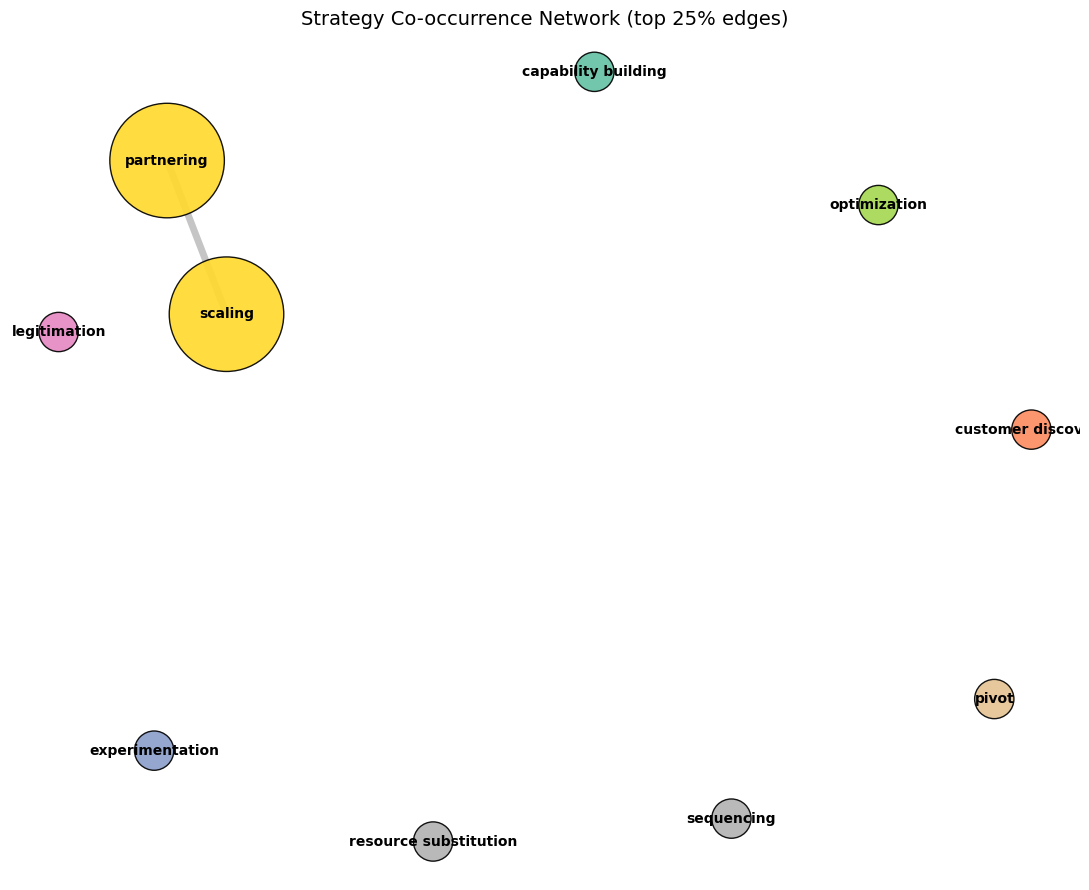

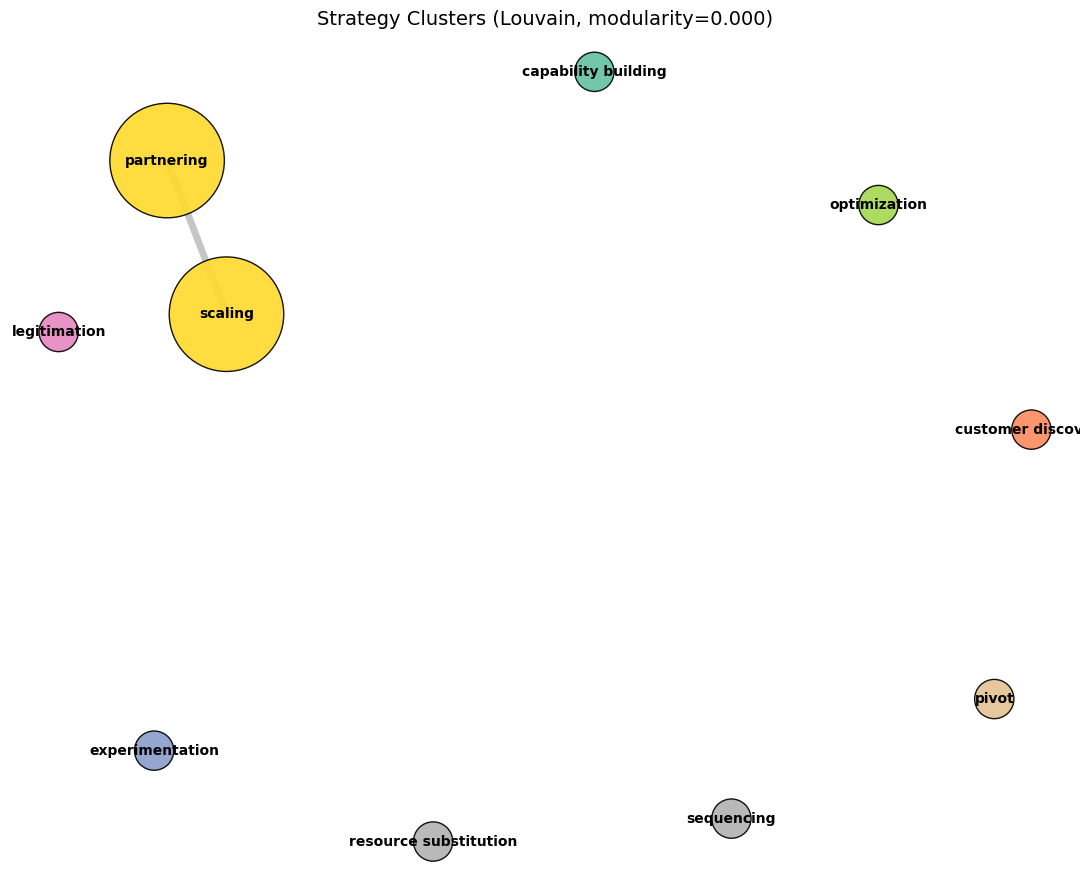

In [10]:
def plot_strategy_network(G, partition, cent, fname, title):
    if G.number_of_edges() == 0:
        print('Empty graph; skipping.'); return
    pos = nx.spring_layout(G, seed=42, weight='weight', k=1.2)
    fig, ax = plt.subplots(figsize=(11,9))
    wd = cent.set_index('strategy')['weighted_degree']
    sizes = [800 + 6000 * wd.loc[n] / max(wd.max(),1) for n in G.nodes]
    clusters = [partition[n] for n in G.nodes]
    weights = np.array([G[u][v]['weight'] for u,v in G.edges])
    edge_widths = 0.5 + 4.5 * (weights/weights.max())
    nx.draw_networkx_edges(G,pos,width=edge_widths,alpha=0.45,edge_color='gray',ax=ax)
    nx.draw_networkx_nodes(G,pos,node_size=sizes,node_color=clusters,cmap=plt.cm.Set2,
                            alpha=0.92,edgecolors='black',linewidths=1.0,ax=ax)
    nx.draw_networkx_labels(G,pos,labels={n:STRATEGY_LABELS[n] for n in G.nodes},
                             font_size=10,font_weight='bold',ax=ax)
    ax.set_title(title, fontsize=14); ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_SENT,fname), dpi=300, bbox_inches='tight')
    plt.show()

plot_strategy_network(G_strat, part_strat, cent_strat,
                       'fig_strategy_network.png', 'Strategy Co-occurrence Network (top 25% edges)')
plot_strategy_network(G_strat, part_strat, cent_strat,
                       'fig_strategy_clusters.png', f'Strategy Clusters (Louvain, modularity={mod_strat:.3f})')


Top 10 strategy 3-step paths:
  strategy_partnering -> strategy_partnering -> strategy_partnering: 51
  strategy_pivot -> strategy_pivot -> strategy_pivot: 19
  strategy_scaling -> strategy_scaling -> strategy_partnering: 11
  strategy_scaling -> strategy_scaling -> strategy_scaling: 11
  strategy_experimentation -> strategy_experimentation -> strategy_experimentation: 11
  strategy_pivot -> strategy_partnering -> strategy_partnering: 10
  strategy_partnering -> strategy_partnering -> strategy_scaling: 9
  strategy_partnering -> strategy_pivot -> strategy_partnering: 8
  strategy_partnering -> strategy_partnering -> strategy_optimization: 7
  strategy_partnering -> strategy_scaling -> strategy_partnering: 7


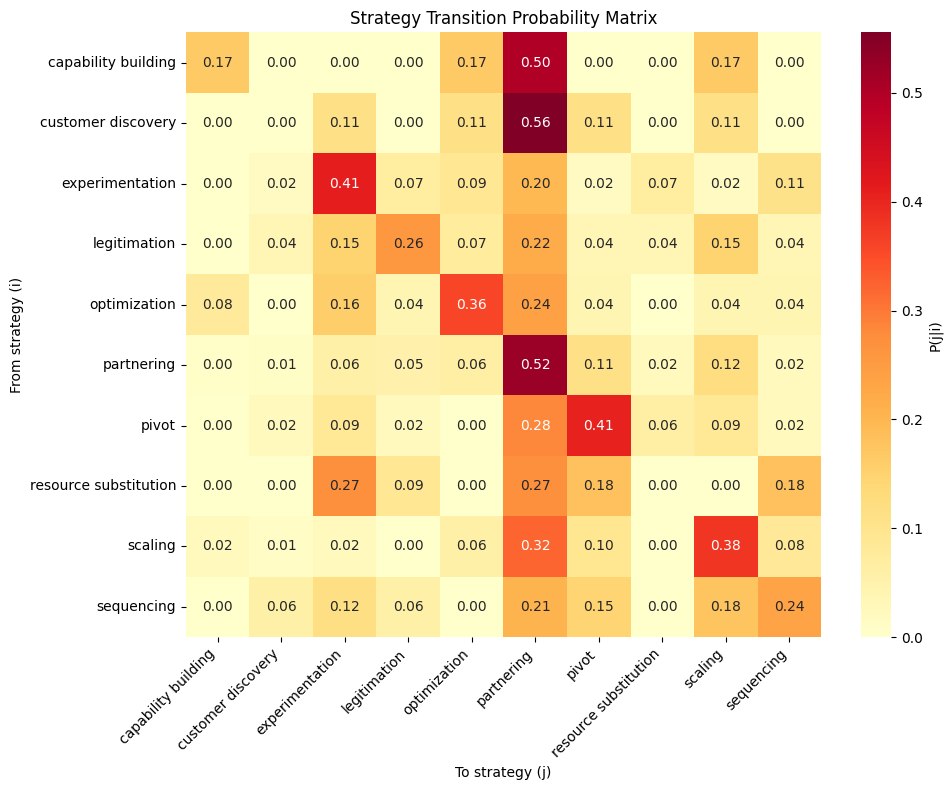

In [11]:
df_sentences['primary'] = df_sentences['labels'].apply(lambda x: x[0] if x else None)

trans = pd.DataFrame(0, index=STRATEGIES, columns=STRATEGIES, dtype=float)
for ep, sub in df_sentences.groupby('episode_id'):
    seq = [p for p in sub.sort_values('sent_idx')['primary'].tolist() if p is not None]
    for i in range(len(seq)-1):
        trans.loc[seq[i], seq[i+1]] += 1

trans_prob = trans.div(trans.sum(axis=1).replace(0,1), axis=0)
trans.to_csv(os.path.join(OUTPUT_SENT,'transition_counts.csv'))
trans_prob.to_csv(os.path.join(OUTPUT_SENT,'transition_matrix.csv'))

paths = Counter()
for ep, sub in df_sentences.groupby('episode_id'):
    seq = [p for p in sub.sort_values('sent_idx')['primary'].tolist() if p is not None]
    for i in range(len(seq)-2):
        paths[(seq[i],seq[i+1],seq[i+2])] += 1
top_paths = paths.most_common(20)
pd.DataFrame([{'s1':a,'s2':b,'s3':c,'count':n} for (a,b,c),n in top_paths]).to_csv(
    os.path.join(OUTPUT_SENT,'top_3step_paths.csv'), index=False)

print('Top 10 strategy 3-step paths:')
for (a,b,c),n in top_paths[:10]:
    print(f'  {a} -> {b} -> {c}: {n}')

fig, ax = plt.subplots(figsize=(10,8))
labs_short = [STRATEGY_LABELS[s] for s in STRATEGIES]
sns.heatmap(trans_prob.values, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=labs_short, yticklabels=labs_short, ax=ax,
            cbar_kws={'label':'P(j|i)'})
ax.set_xlabel('To strategy (j)'); ax.set_ylabel('From strategy (i)')
ax.set_title('Strategy Transition Probability Matrix')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_SENT,'fig_transition_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()


## EPISODE-LEVEL LAYER
Episode similarity network (nodes = episodes, edges = strategy-profile similarity). Built from a shared episode × strategy intensity matrix that also drives episode-level centrality, clustering, and constraint linkage.

In [12]:
episodes_list = sorted(df_sentences.episode_id.unique())
ep_counts = pd.DataFrame(0, index=episodes_list, columns=STRATEGIES, dtype=float)
for _, r in df_labels.iterrows():
    ep_counts.loc[r['episode_id'], r['strategy']] += 1
ep_counts.to_csv(os.path.join(OUTPUT_EP,'episode_strategy_counts.csv'))

ep_n_sent = df_sentences.groupby('episode_id').size().reindex(episodes_list).fillna(0)
ep_intensity = ep_counts.div(ep_n_sent.replace(0,1), axis=0)
ep_intensity.to_csv(os.path.join(OUTPUT_EP,'episode_strategy_intensity.csv'))

ep_share = ep_counts.div(ep_counts.sum(axis=1).replace(0,1), axis=0)
ep_share.to_csv(os.path.join(OUTPUT_EP,'episode_strategy_share.csv'))

ep_presence = (ep_counts > 0).astype(int)
ep_presence.to_csv(os.path.join(OUTPUT_EP,'episode_strategy_presence.csv'))

ep_summary = pd.DataFrame({
    'episode_id': episodes_list,
    'n_sentences': ep_n_sent.values,
    'n_label_instances': ep_counts.sum(axis=1).values,
    'n_unique_strategies': ep_presence.sum(axis=1).values,
    'dominant_strategy': ep_share.idxmax(axis=1).where(ep_share.sum(axis=1)>0, None).values,
    'shannon_diversity': ep_share.apply(lambda r: -np.sum([p*np.log(p) for p in r if p>0]) if r.sum()>0 else 0, axis=1).values
})
ep_summary.to_csv(os.path.join(OUTPUT_EP,'episode_summary.csv'), index=False)

print(f'Episodes: {len(episodes_list)}')
print(f'Avg unique strategies per episode: {ep_summary.n_unique_strategies.mean():.2f}')
print(f'Avg Shannon diversity: {ep_summary.shannon_diversity.mean():.3f}')
print('\nDominant strategy distribution:')
print(ep_summary.dominant_strategy.value_counts())


Episodes: 124
Avg unique strategies per episode: 2.59
Avg Shannon diversity: 0.713

Dominant strategy distribution:
dominant_strategy
strategy_partnering             55
strategy_scaling                17
strategy_experimentation        17
strategy_pivot                  12
strategy_optimization            8
strategy_legitimation            6
strategy_sequencing              4
strategy_customer_discovery      1
strategy_capability_building     1
Name: count, dtype: int64


In [13]:
EP_VECTOR = ep_share

valid_idx = EP_VECTOR.sum(axis=1) > 0
ep_used = EP_VECTOR[valid_idx]
print(f'Episodes used (>=1 strategy): {len(ep_used)} / {len(EP_VECTOR)}')

sim = cosine_similarity(ep_used.values)
sim_df = pd.DataFrame(sim, index=ep_used.index, columns=ep_used.index)
sim_df.to_csv(os.path.join(OUTPUT_EP,'episode_similarity.csv'))

EP_THRESHOLD = 0.5
G_ep = nx.Graph()
for ep in ep_used.index: G_ep.add_node(ep)
for i, a in enumerate(ep_used.index):
    for j, b in enumerate(ep_used.index):
        if j <= i: continue
        v = float(sim_df.loc[a,b])
        if v >= EP_THRESHOLD: G_ep.add_edge(a, b, weight=v)

ep_density = nx.density(G_ep)
n_iso = sum(1 for n in G_ep.nodes if G_ep.degree(n)==0)
print(f'Episode network: {G_ep.number_of_nodes()} nodes, {G_ep.number_of_edges()} edges')
print(f'Density: {ep_density:.4f} | Isolates (deg=0): {n_iso}')

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
thresh_rows = []
for t in thresholds:
    Gt = nx.Graph()
    for ep in ep_used.index: Gt.add_node(ep)
    for i,a in enumerate(ep_used.index):
        for j,b in enumerate(ep_used.index):
            if j <= i: continue
            v = float(sim_df.loc[a,b])
            if v >= t: Gt.add_edge(a,b,weight=v)
    thresh_rows.append({'threshold':t,'edges':Gt.number_of_edges(),
                         'density':round(nx.density(Gt),4),
                         'isolates':sum(1 for n in Gt.nodes if Gt.degree(n)==0)})
thresh_df = pd.DataFrame(thresh_rows)
thresh_df.to_csv(os.path.join(OUTPUT_EP,'episode_threshold_sweep.csv'), index=False)
print('\nThreshold sweep:')
print(thresh_df)


Episodes used (>=1 strategy): 121 / 124
Episode network: 121 nodes, 3263 edges
Density: 0.4494 | Isolates (deg=0): 0

Threshold sweep:
   threshold  edges  density  isolates
0        0.3   4565   0.6288         0
1        0.4   3886   0.5353         0
2        0.5   3263   0.4494         0
3        0.6   2691   0.3707         0
4        0.7   2046   0.2818         0


In [14]:
deg_ep  = nx.degree_centrality(G_ep)
wdeg_ep = dict(G_ep.degree(weight='weight'))
btw_ep  = nx.betweenness_centrality(G_ep, weight='weight', normalized=True)
try:
    eig_ep = nx.eigenvector_centrality_numpy(G_ep, weight='weight')
except Exception:
    eig_ep = {n:0.0 for n in G_ep.nodes}

cent_ep = pd.DataFrame({
    'episode_id': list(G_ep.nodes),
    'degree_centrality':[deg_ep.get(n,0) for n in G_ep.nodes],
    'weighted_degree':  [wdeg_ep.get(n,0) for n in G_ep.nodes],
    'betweenness':      [btw_ep.get(n,0) for n in G_ep.nodes],
    'eigenvector':      [eig_ep.get(n,0) for n in G_ep.nodes]
}).sort_values('weighted_degree', ascending=False)
cent_ep = cent_ep.merge(ep_summary, on='episode_id', how='left')
cent_ep.to_csv(os.path.join(OUTPUT_EP,'centrality_episode.csv'), index=False)

if G_ep.number_of_edges() > 0:
    part_ep = community_louvain.best_partition(G_ep, weight='weight', random_state=42)
    mod_ep  = community_louvain.modularity(part_ep, G_ep, weight='weight')
else:
    part_ep = {n:i for i,n in enumerate(G_ep.nodes)}; mod_ep = 0.0

n_ep_clusters = len(set(part_ep.values()))
ep_clust = pd.DataFrame([{'episode_id':k,'cluster':v} for k,v in part_ep.items()])
ep_clust = ep_clust.merge(ep_summary, on='episode_id', how='left')
ep_clust.to_csv(os.path.join(OUTPUT_EP,'episode_clusters.csv'), index=False)

with open(os.path.join(OUTPUT_EP,'episode_network_metrics.txt'),'w') as f:
    f.write(f'threshold\t{EP_THRESHOLD}\n')
    f.write(f'nodes\t{G_ep.number_of_nodes()}\n')
    f.write(f'edges\t{G_ep.number_of_edges()}\n')
    f.write(f'density\t{ep_density:.6f}\n')
    f.write(f'modularity\t{mod_ep:.6f}\n')
    f.write(f'n_communities\t{n_ep_clusters}\n')

print(f'Modularity: {mod_ep:.4f} | Communities: {n_ep_clusters}')
print(f'\nTop 10 central episodes (weighted degree):')
print(cent_ep.head(10)[['episode_id','weighted_degree','betweenness','dominant_strategy','n_unique_strategies']])


Modularity: 0.1908 | Communities: 4

Top 10 central episodes (weighted degree):
                                          episode_id  weighted_degree  \
0                        ep44-a-look-into-the-future        66.319947   
1  ep90-preparing-brands-for-the-future-as-a-cons...        66.319947   
2  ep90-preparing-brands-for-the-future-as-a-cons...        66.319947   
3                        ep30-the-leap-in-technology        66.165958   
4                       ep124-the-leap-in-technology        66.165958   
5          ep02-the-international-founder-experience        64.900964   
6  ep108-b2b-marketing-insights-volvo-s-strategy-...        64.786298   
7                              ep42-the-gifted-house        64.781107   
8                         ep34-the-startup-therapist        64.666198   
9                        ep123-the-startup-therapist        64.666198   

   betweenness    dominant_strategy  n_unique_strategies  
0     0.000980  strategy_partnering                    3 

Episode cluster profiles (mean strategy shares):
   cluster  n_episodes             top1_strategy  top1_share  \
0        0          51       strategy_partnering       0.747   
1        1          35          strategy_scaling       0.407   
2        2          14  strategy_experimentation       0.507   
3        3          21            strategy_pivot       0.445   

           top2_strategy  top2_share        top3_strategy  top3_share  
0  strategy_legitimation       0.076       strategy_pivot       0.049  
1  strategy_optimization       0.176  strategy_partnering       0.147  
2    strategy_partnering       0.258     strategy_scaling       0.078  
3    strategy_partnering       0.254     strategy_scaling       0.083  


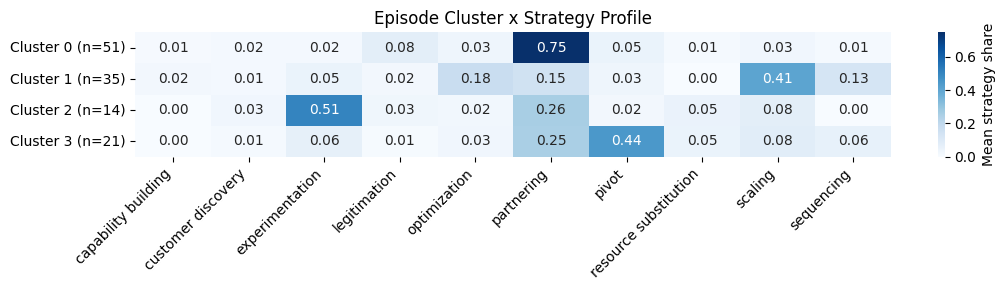

In [15]:
rows = []
for c in sorted(set(part_ep.values())):
    members = [ep for ep, cc in part_ep.items() if cc == c]
    if not members: continue
    profile = ep_share.loc[members].mean(axis=0)
    top = profile.sort_values(ascending=False)
    rows.append({
        'cluster': c,
        'n_episodes': len(members),
        'top1_strategy': top.index[0], 'top1_share': round(float(top.iloc[0]),3),
        'top2_strategy': top.index[1] if len(top)>1 else '', 'top2_share': round(float(top.iloc[1]),3) if len(top)>1 else 0.0,
        'top3_strategy': top.index[2] if len(top)>2 else '', 'top3_share': round(float(top.iloc[2]),3) if len(top)>2 else 0.0
    })
cluster_profiles = pd.DataFrame(rows)
cluster_profiles.to_csv(os.path.join(OUTPUT_EP,'episode_cluster_profiles.csv'), index=False)
print('Episode cluster profiles (mean strategy shares):')
print(cluster_profiles)

cluster_strategy_matrix = pd.DataFrame(0.0, index=sorted(set(part_ep.values())), columns=STRATEGIES)
for c in cluster_strategy_matrix.index:
    members = [ep for ep, cc in part_ep.items() if cc == c]
    cluster_strategy_matrix.loc[c] = ep_share.loc[members].mean(axis=0)
cluster_strategy_matrix.to_csv(os.path.join(OUTPUT_EP,'cluster_strategy_profile_matrix.csv'))

fig, ax = plt.subplots(figsize=(11, max(3, 0.5*len(cluster_strategy_matrix))))
sns.heatmap(cluster_strategy_matrix.values, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[STRATEGY_LABELS[s] for s in STRATEGIES],
            yticklabels=[f'Cluster {c} (n={len([ep for ep,cc in part_ep.items() if cc==c])})' for c in cluster_strategy_matrix.index],
            ax=ax, cbar_kws={'label':'Mean strategy share'})
ax.set_title('Episode Cluster x Strategy Profile')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_EP,'fig_cluster_strategy_profile.png'), dpi=300, bbox_inches='tight')
plt.show()


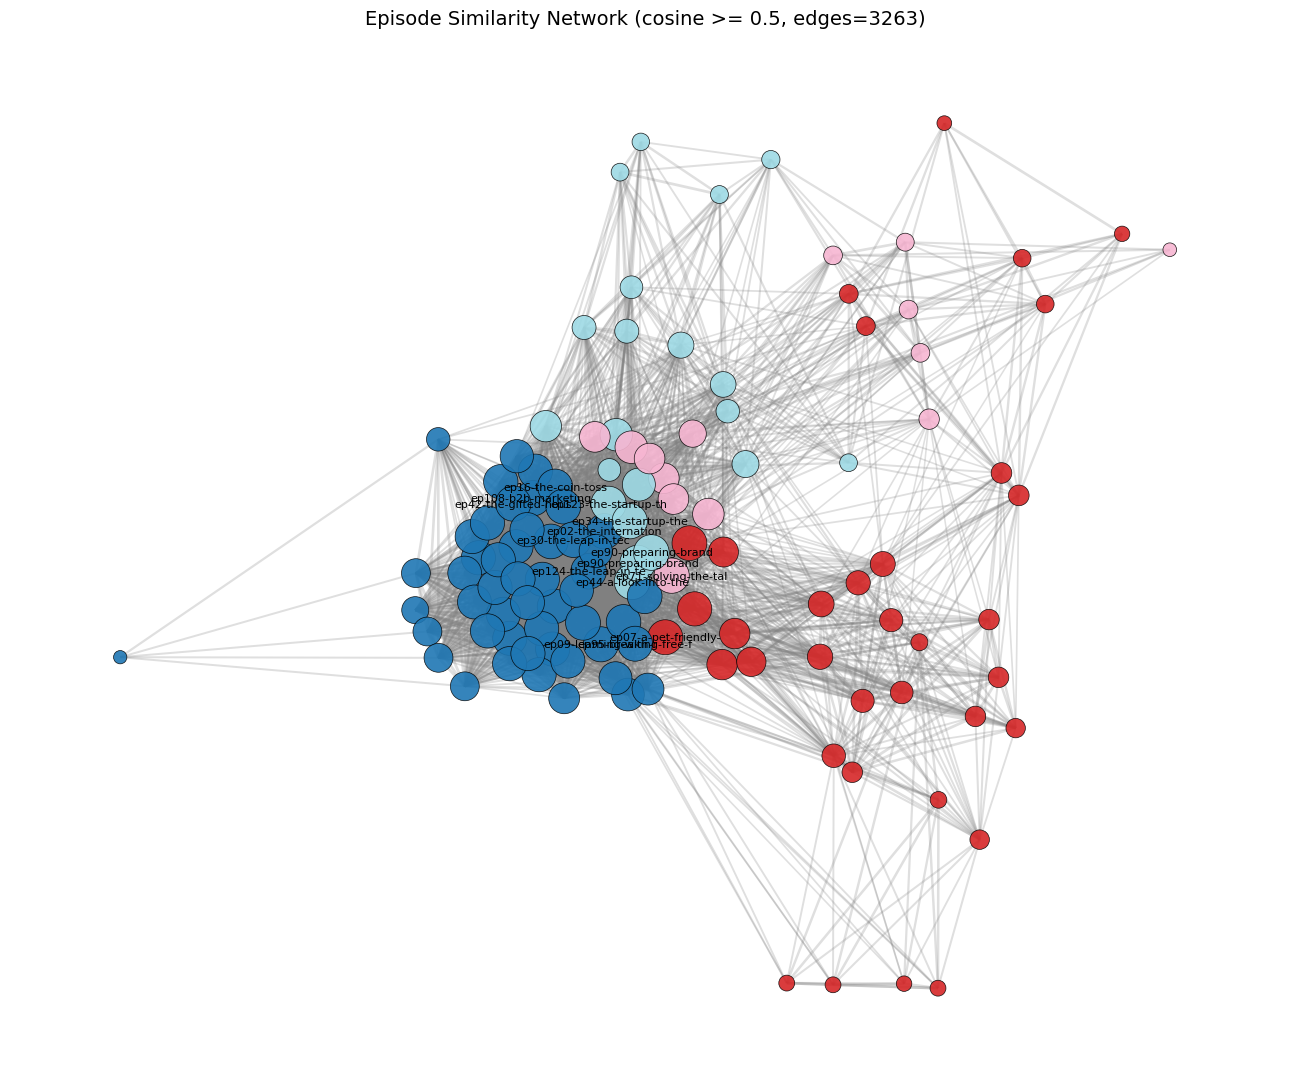

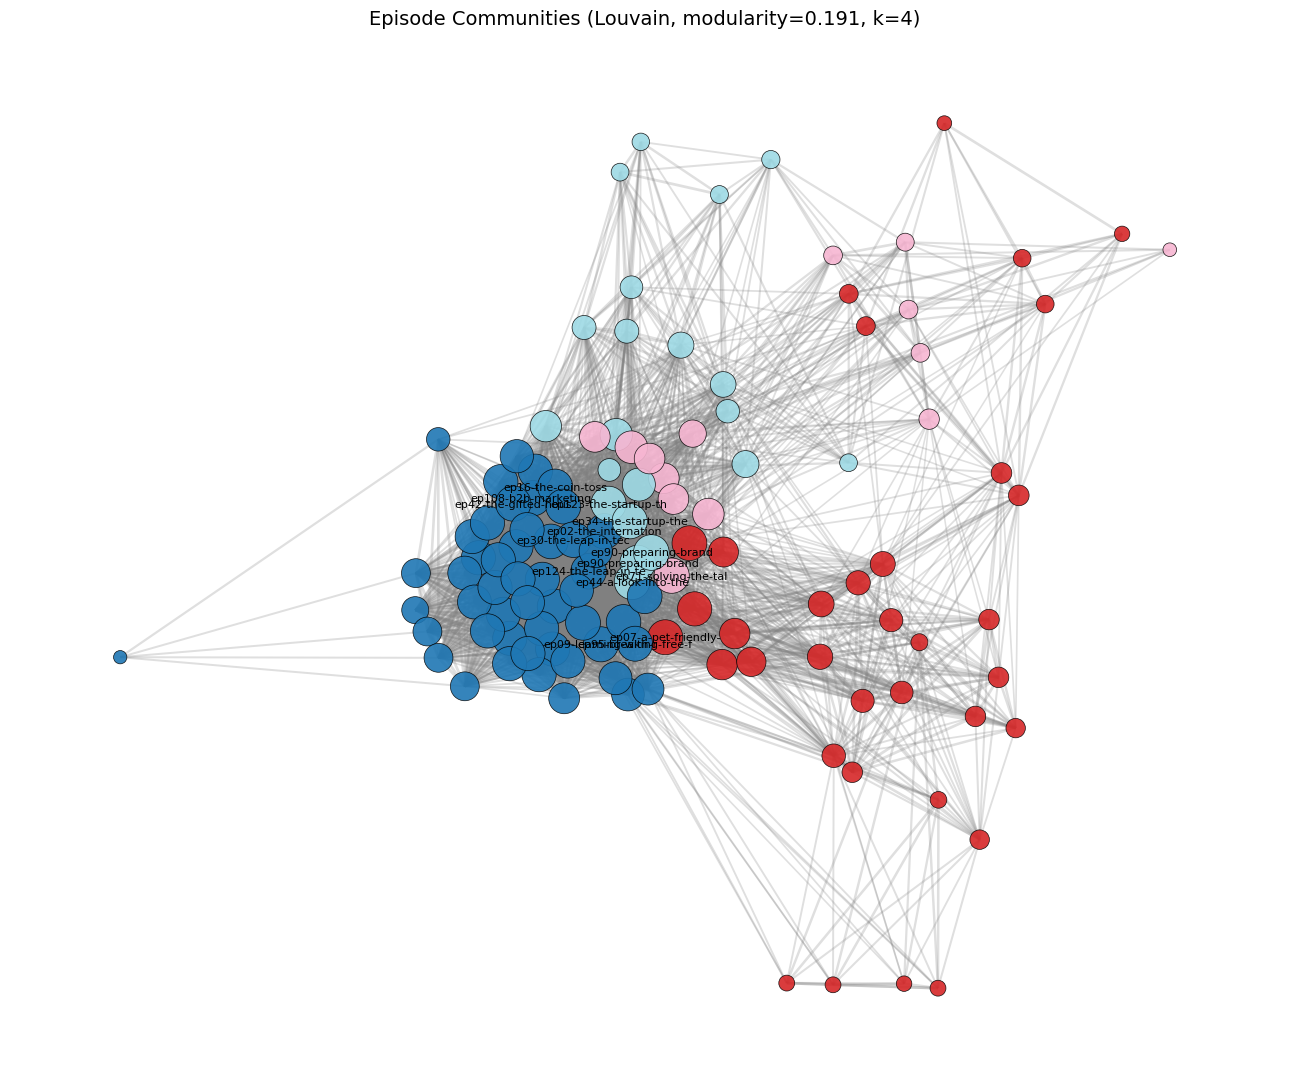

In [16]:
def plot_episode_network(G, partition, cent, fname, title):
    if G.number_of_nodes() == 0:
        print('Empty graph; skipping.'); return
    pos = nx.spring_layout(G, seed=42, weight='weight', k=0.6)
    fig, ax = plt.subplots(figsize=(13,11))
    wd = cent.set_index('episode_id')['weighted_degree']
    sizes = [60 + 600 * wd.loc[n] / max(wd.max(),1) for n in G.nodes]
    clusters = [partition[n] for n in G.nodes]
    if G.number_of_edges() > 0:
        weights = np.array([G[u][v]['weight'] for u,v in G.edges])
        edge_widths = 0.2 + 1.8 * (weights/weights.max())
        nx.draw_networkx_edges(G,pos,width=edge_widths,alpha=0.25,edge_color='gray',ax=ax)
    nx.draw_networkx_nodes(G,pos,node_size=sizes,node_color=clusters,cmap=plt.cm.tab20,
                            alpha=0.9,edgecolors='black',linewidths=0.5,ax=ax)
    top_n = cent.head(15)['episode_id'].tolist()
    nx.draw_networkx_labels(G,pos,labels={n:str(n)[:20] for n in top_n},font_size=8,ax=ax)
    ax.set_title(title, fontsize=14); ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_EP,fname), dpi=300, bbox_inches='tight')
    plt.show()

plot_episode_network(G_ep, part_ep, cent_ep,
                      'fig_episode_network.png',
                      f'Episode Similarity Network (cosine >= {EP_THRESHOLD}, edges={G_ep.number_of_edges()})')
plot_episode_network(G_ep, part_ep, cent_ep,
                      'fig_episode_clusters.png',
                      f'Episode Communities (Louvain, modularity={mod_ep:.3f}, k={n_ep_clusters})')


In [17]:
CONSTRAINT_DICT_PATH   = os.path.join(BASE_OUT, 'constraint_dictionary.json')
CONSTRAINT_LABELS_PATH = os.path.join(BASE_OUT, 'constraint_labels.csv')

df_cstr = None
if os.path.exists(CONSTRAINT_LABELS_PATH):
    df_cstr = pd.read_csv(CONSTRAINT_LABELS_PATH)
    print(f'Loaded constraint labels: {len(df_cstr)} rows')
elif os.path.exists(CONSTRAINT_DICT_PATH):
    with open(CONSTRAINT_DICT_PATH) as f: CSTR_DICT = json.load(f)
    cstr_compiled = {c: re.compile('|'.join([r'\b'+re.escape(p)+r'\b' for p in ph]), re.IGNORECASE) for c,ph in CSTR_DICT.items()}
    rows = []
    for _, r in df_sentences.iterrows():
        for c, pat in cstr_compiled.items():
            if pat.search(r['text']):
                rows.append({'episode_id':r['episode_id'],'sentence_id':r['sentence_id'],
                              'sent_idx':r['sent_idx'],'constraint':c})
    df_cstr = pd.DataFrame(rows)
    df_cstr.to_csv(os.path.join(OUTPUT_PATH,'constraint_labels.csv'), index=False)
    print(f'Built constraint labels from dictionary: {len(df_cstr)} rows')
else:
    print('No constraint dictionary or labels found. Skipping constraint linkage.')

if df_cstr is not None and len(df_cstr) > 0:
    constraints = sorted(df_cstr['constraint'].unique())

    # SENTENCE-LEVEL: P(strategy | constraint) using +/-2 sentence window
    cstr_by_sent = df_cstr.groupby('sentence_id')['constraint'].apply(list).to_dict()
    cs_matrix = pd.DataFrame(0, index=constraints, columns=STRATEGIES, dtype=float)
    WIN = 2
    for ep, sub in df_sentences.groupby('episode_id'):
        sub = sub.sort_values('sent_idx').reset_index(drop=True); n = len(sub)
        for i in range(n):
            sid = sub.iloc[i]['sentence_id']
            cs = cstr_by_sent.get(sid, [])
            if not cs: continue
            lo, hi = max(0,i-WIN), min(n,i+WIN+1)
            strats = list({s for j in range(lo,hi) for s in sub.iloc[j]['labels']})
            for c in set(cs):
                for s in strats: cs_matrix.loc[c,s] += 1
    cs_prob = cs_matrix.div(cs_matrix.sum(axis=1).replace(0,1), axis=0)
    cs_matrix.to_csv(os.path.join(OUTPUT_SENT,'constraint_strategy_counts.csv'))
    cs_prob.to_csv(os.path.join(OUTPUT_SENT,'constraint_strategy_prob.csv'))

    fig, ax = plt.subplots(figsize=(11, max(4, 0.6*len(constraints))))
    sns.heatmap(cs_prob.values, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[STRATEGY_LABELS[s] for s in STRATEGIES],
                yticklabels=constraints, ax=ax, cbar_kws={'label':'P(strategy | constraint)'})
    ax.set_title('Sentence-level: Constraint -> Strategy')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_SENT,'fig_constraint_strategy_heatmap.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Strategy-bundle (cluster) view
    bundles = sorted(set(part_strat.values()))
    cb = pd.DataFrame(0.0, index=constraints, columns=[f'bundle_{b}' for b in bundles])
    for c in constraints:
        for b in bundles:
            members = [s for s,bb in part_strat.items() if bb==b]
            cb.loc[c, f'bundle_{b}'] = cs_matrix.loc[c, members].sum()
    cb_prob = cb.div(cb.sum(axis=1).replace(0,1), axis=0)
    cb_prob.to_csv(os.path.join(OUTPUT_SENT,'constraint_bundle_prob.csv'))
    print('\nConstraint -> Strategy Bundle:')
    print(cb_prob.round(3))

    # EPISODE-LEVEL: episode x constraint presence + episode-cluster x constraint
    ep_cstr_counts = pd.DataFrame(0, index=episodes_list, columns=constraints, dtype=float)
    for _, r in df_cstr.iterrows():
        ep_cstr_counts.loc[r['episode_id'], r['constraint']] += 1
    ep_cstr_counts.to_csv(os.path.join(OUTPUT_EP,'episode_constraint_counts.csv'))
    ep_cstr_share = ep_cstr_counts.div(ep_cstr_counts.sum(axis=1).replace(0,1), axis=0)
    ep_cstr_share.to_csv(os.path.join(OUTPUT_EP,'episode_constraint_share.csv'))

    cluster_constraint = pd.DataFrame(0.0, index=sorted(set(part_ep.values())), columns=constraints)
    for c in cluster_constraint.index:
        members = [ep for ep, cc in part_ep.items() if cc == c]
        if members:
            cluster_constraint.loc[c] = ep_cstr_share.loc[ep_cstr_share.index.intersection(members)].mean(axis=0)
    cluster_constraint.to_csv(os.path.join(OUTPUT_EP,'episode_cluster_constraint_profile.csv'))

    fig, ax = plt.subplots(figsize=(10, max(3, 0.5*len(cluster_constraint))))
    sns.heatmap(cluster_constraint.values, annot=True, fmt='.2f', cmap='Oranges',
                xticklabels=constraints,
                yticklabels=[f'Cluster {c}' for c in cluster_constraint.index],
                ax=ax, cbar_kws={'label':'Mean constraint share'})
    ax.set_title('Episode-level: Cluster x Constraint Profile')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_EP,'fig_cluster_constraint_profile.png'), dpi=300, bbox_inches='tight')
    plt.show()


No constraint dictionary or labels found. Skipping constraint linkage.


In [18]:
val_rows = []

# Strategy-network sensitivity
ranks_base = cent_strat.set_index('strategy')['weighted_degree']
for top_pct in [0.20, 0.25, 0.30, 0.35]:
    Gx = build_graph(co_matrix, top_pct=top_pct)
    if Gx.number_of_edges() == 0:
        val_rows.append({'layer':'strategy','test':'edge_threshold','param':f'top_{top_pct}','metric':'edges','value':0}); continue
    wdx = dict(Gx.degree(weight='weight'))
    rx = pd.Series([wdx.get(s,0) for s in STRATEGIES], index=STRATEGIES)
    rho, _ = spearmanr(ranks_base.values, rx.values)
    px = community_louvain.best_partition(Gx, weight='weight', random_state=42)
    mx = community_louvain.modularity(px, Gx, weight='weight')
    ari = adjusted_rand_score([part_strat[s] for s in STRATEGIES],[px[s] for s in STRATEGIES])
    val_rows.extend([
        {'layer':'strategy','test':'edge_threshold','param':f'top_{top_pct}','metric':'edges','value':Gx.number_of_edges()},
        {'layer':'strategy','test':'edge_threshold','param':f'top_{top_pct}','metric':'spearman_wdeg','value':round(float(rho),4)},
        {'layer':'strategy','test':'edge_threshold','param':f'top_{top_pct}','metric':'modularity','value':round(float(mx),4)},
        {'layer':'strategy','test':'edge_threshold','param':f'top_{top_pct}','metric':'ari_vs_base','value':round(float(ari),4)}
    ])

# Window sensitivity (strategy layer)
for win in [0,1,2]:
    cox = build_cooccurrence(df_sentences, window=win)
    Gx = build_graph(cox, top_pct=0.25)
    if Gx.number_of_edges() == 0:
        val_rows.append({'layer':'strategy','test':'window','param':f'win_{win}','metric':'edges','value':0}); continue
    wdx = dict(Gx.degree(weight='weight'))
    rx = pd.Series([wdx.get(s,0) for s in STRATEGIES], index=STRATEGIES)
    rho, _ = spearmanr(ranks_base.values, rx.values)
    px = community_louvain.best_partition(Gx, weight='weight', random_state=42)
    mx = community_louvain.modularity(px, Gx, weight='weight')
    ari = adjusted_rand_score([part_strat[s] for s in STRATEGIES],[px[s] for s in STRATEGIES])
    val_rows.extend([
        {'layer':'strategy','test':'window','param':f'win_{win}','metric':'edges','value':Gx.number_of_edges()},
        {'layer':'strategy','test':'window','param':f'win_{win}','metric':'spearman_wdeg','value':round(float(rho),4)},
        {'layer':'strategy','test':'window','param':f'win_{win}','metric':'modularity','value':round(float(mx),4)},
        {'layer':'strategy','test':'window','param':f'win_{win}','metric':'ari_vs_base','value':round(float(ari),4)}
    ])

# Bootstrap (strategy clusters)
rng = np.random.default_rng(42)
ari_boot = []
for _ in range(20):
    samp = df_sentences.sample(frac=0.8, random_state=int(rng.integers(0,1e9)))
    cox = build_cooccurrence(samp, window=0)
    Gx = build_graph(cox, top_pct=0.25)
    if Gx.number_of_edges() == 0: continue
    px = community_louvain.best_partition(Gx, weight='weight', random_state=42)
    ari_boot.append(adjusted_rand_score([part_strat[s] for s in STRATEGIES],[px[s] for s in STRATEGIES]))
if ari_boot:
    val_rows.extend([
        {'layer':'strategy','test':'bootstrap_80pct','param':'n=20','metric':'mean_ari','value':round(float(np.mean(ari_boot)),4)},
        {'layer':'strategy','test':'bootstrap_80pct','param':'n=20','metric':'std_ari','value':round(float(np.std(ari_boot)),4)}
    ])

# Episode-network threshold sensitivity
base_part_ep = part_ep
for t in [0.4, 0.5, 0.6, 0.7]:
    Gt = nx.Graph()
    for ep in ep_used.index: Gt.add_node(ep)
    for i,a in enumerate(ep_used.index):
        for j,b in enumerate(ep_used.index):
            if j<=i: continue
            v = float(sim_df.loc[a,b])
            if v >= t: Gt.add_edge(a,b,weight=v)
    if Gt.number_of_edges() == 0:
        val_rows.append({'layer':'episode','test':'similarity_threshold','param':f't_{t}','metric':'edges','value':0}); continue
    pt = community_louvain.best_partition(Gt, weight='weight', random_state=42)
    mt = community_louvain.modularity(pt, Gt, weight='weight')
    common = list(set(base_part_ep.keys()) & set(pt.keys()))
    ari = adjusted_rand_score([base_part_ep[n] for n in common],[pt[n] for n in common]) if common else 0.0
    val_rows.extend([
        {'layer':'episode','test':'similarity_threshold','param':f't_{t}','metric':'edges','value':Gt.number_of_edges()},
        {'layer':'episode','test':'similarity_threshold','param':f't_{t}','metric':'density','value':round(nx.density(Gt),4)},
        {'layer':'episode','test':'similarity_threshold','param':f't_{t}','metric':'modularity','value':round(float(mt),4)},
        {'layer':'episode','test':'similarity_threshold','param':f't_{t}','metric':'ari_vs_base','value':round(float(ari),4)}
    ])

val_df = pd.DataFrame(val_rows)
val_df.to_csv(os.path.join(OUTPUT_PATH,'validation_metrics.csv'), index=False)
print(val_df)


       layer                  test     param         metric      value
0   strategy        edge_threshold   top_0.2          edges     1.0000
1   strategy        edge_threshold   top_0.2  spearman_wdeg    -0.2500
2   strategy        edge_threshold   top_0.2     modularity     0.0000
3   strategy        edge_threshold   top_0.2    ari_vs_base     1.0000
4   strategy        edge_threshold  top_0.25          edges     1.0000
5   strategy        edge_threshold  top_0.25  spearman_wdeg    -0.2500
6   strategy        edge_threshold  top_0.25     modularity     0.0000
7   strategy        edge_threshold  top_0.25    ari_vs_base     1.0000
8   strategy        edge_threshold   top_0.3          edges     1.0000
9   strategy        edge_threshold   top_0.3  spearman_wdeg    -0.2500
10  strategy        edge_threshold   top_0.3     modularity     0.0000
11  strategy        edge_threshold   top_0.3    ari_vs_base     1.0000
12  strategy        edge_threshold  top_0.35          edges     2.0000
13  st

In [19]:
summary = {
    'data':{
        'n_episodes': int(df_sentences.episode_id.nunique()),
        'n_sentences': int(len(df_sentences)),
        'n_labeled_sentences': int((df_sentences.n_labels>0).sum()),
        'n_label_instances': int(len(df_labels)),
        'n_strategies': len(STRATEGIES)
    },
    'strategy_layer':{
        'graph_nodes': G_strat.number_of_nodes(),
        'graph_edges': G_strat.number_of_edges(),
        'modularity': round(float(mod_strat),4),
        'n_clusters': int(clust_strat.cluster.nunique()),
        'bridge_strategy': max(btw.items(), key=lambda x:x[1])[0] if btw else None,
        'top_centrality': cent_strat.iloc[0]['strategy'] if len(cent_strat)>0 else None
    },
    'episode_layer':{
        'graph_nodes': G_ep.number_of_nodes(),
        'graph_edges': G_ep.number_of_edges(),
        'density': round(float(ep_density),4),
        'modularity': round(float(mod_ep),4),
        'n_communities': int(n_ep_clusters),
        'similarity_threshold': EP_THRESHOLD,
        'top_central_episode': cent_ep.iloc[0]['episode_id'] if len(cent_ep)>0 else None
    }
}
with open(os.path.join(OUTPUT_PATH,'run_summary.json'),'w') as f:
    json.dump(summary, f, indent=2)

print('=== RUN SUMMARY ===')
print(json.dumps(summary, indent=2))

print('\n=== OUTPUT DIRECTORIES ===')
for label, p in [('shared', OUTPUT_PATH), ('sentence', OUTPUT_SENT), ('episode', OUTPUT_EP)]:
    print(f'\n[{label}] {p}')
    for f in sorted(os.listdir(p)): print(f'  {f}')

print('\n=== FIGURE DIRECTORIES ===')
for label, p in [('sentence', FIGURE_SENT), ('episode', FIGURE_EP)]:
    print(f'\n[{label}] {p}')
    for f in sorted(os.listdir(p)): print(f'  {f}')


=== RUN SUMMARY ===
{
  "data": {
    "n_episodes": 124,
    "n_sentences": 38508,
    "n_labeled_sentences": 658,
    "n_label_instances": 666,
    "n_strategies": 10
  },
  "strategy_layer": {
    "graph_nodes": 10,
    "graph_edges": 1,
    "modularity": 0.0,
    "n_clusters": 9,
    "bridge_strategy": "strategy_capability_building",
    "top_centrality": "strategy_scaling"
  },
  "episode_layer": {
    "graph_nodes": 121,
    "graph_edges": 3263,
    "density": 0.4494,
    "modularity": 0.1908,
    "n_communities": 4,
    "similarity_threshold": 0.5,
    "top_central_episode": "ep44-a-look-into-the-future"
  }
}

=== OUTPUT DIRECTORIES ===

[shared] /content/drive/MyDrive/Colab Notebooks/IFResearch/Strategy/outputs
  centrality.csv
  cluster_assignment.csv
  co_matrix.csv
  co_matrix_jaccard.csv
  episode_clusters.csv
  episode_network_metrics.txt
  episode_similarity.csv
  labels.csv
  modularity.txt
  run_summary.json
  sentences.csv
  strategy_dictionary.json
  strategy_frequenc